Because my return over two years was -0.48% with a Sharpe Ratio of -0.8725, I want to test to see wether KO and PEP are actually cointegrated and what theyre half life is

In [6]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys

sys.path.append('../')
from src.data_loader import fetch_multiple_stocks_close

df = fetch_multiple_stocks_close(["KO", "PEP"], "2020-01-01", "2024-01-01")

#COINTEGRATION TEST
logp = np.log(df[['KO', 'PEP']].dropna())
split = "2021-12-31"
form = logp.loc[:split]

_, pval, _ = coint(form['KO'], form['PEP'])
ols = sm.OLS(form['KO'], sm.add_constant(form['PEP'])).fit()
a, beta = ols.params['const'], ols.params['PEP']

spread = logp['KO'] - (a + beta *logp['PEP'])
z = (spread - spread.rolling(30).mean()) / spread.rolling(30).std()
z_trade = z.loc[split:].iloc[1:]

print(f"P-Value is: {pval:.4f}")

[*********************100%***********************]  2 of 2 completed

P-Value is: 0.1587


The P-Value is fairly large. pval > 0.05 suggests that during this time period, we can't rule out that the spread is random rather than mean-reverting. Although the test doesn't prove that KO and PEP aren't cointegrated, it is a reason not to trade them using this strategy. This is because we are relying on hope, rather than statistical significance that when |z|>2, the spread will snap back.

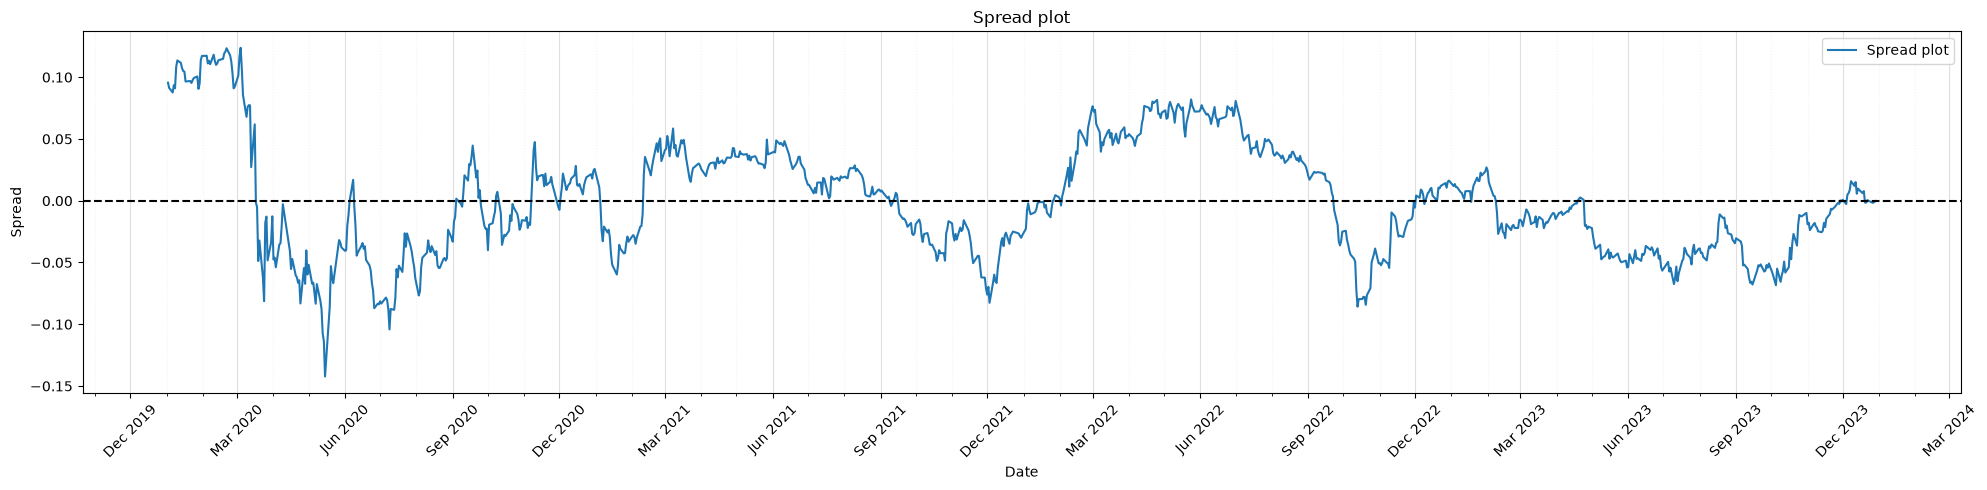

In [7]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.plot(logp.index, spread, label='Spread plot')

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.grid(True, which='major', axis='x', alpha=0.4, linestyle='-')
ax.grid(True, which='minor', axis='x', alpha=0.15, linestyle=':')

ax.axhline(0, c='k', ls='--')
ax.set_title("Spread plot")
ax.set_ylabel("Spread")
ax.set_xlabel("Date")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

On inspection of the chart, we can see that the relationship between KO and PEP seems to be quite loose, but potentially mean reverting. Something we can do to check this is compute the half life, which will tell us how long the spread generally takes to 'snap back'.

In [8]:
s = spread.loc[:split]
d = pd.DataFrame({"ds": s.diff(), "lag": s.shift(1)}).dropna()

fit = sm.OLS(d["ds"], sm.add_constant(d["lag"])).fit()
b, se = fit.params["lag"], fit.bse["lag"]

def half_life(b):
    return -np.log(2) / np.log(1 + b) if -1 < b < 0 else np.inf

print(f"b = {b:.4f}, t-stat = {b/se:.2f}")
print(f"half-life: {half_life(b):.1f} days")
print(f"rough range: {half_life(b - 2*se):.1f} to {half_life(b + 2*se):.1f} days")

b = -0.0285, t-stat = -2.87
half-life: 23.9 days
rough range: 14.0 to 79.6 days


Putting this result back with the p value, we get a weak p value and a moderate half life. The half-life of around 24 days tells us that if the spread mean-reverts, it does so at a resonable speed. However, the cointegration test tells us that the data doesn't confirm that the pair actually do mean revert. There is also a high range from 14-80 days, and the higher end of that range would be enough to cause many poor trades.

Using this information, we should treat KO/PEP as a potential pair, but with a lack of statistial evidence. I would like to wuickly rerun the backtest but with a few tweaks and see if they change anything. Notable, I would like to change the window from 30 days to 60 days, because of the large range on the half life:

In [9]:
from src.backtester import backtest_pairs_trading_strategy


tickers = ["KO", "PEP"]
train_start = "2018-01-01"
train_end = "2021-12-31"
test_start = "2022-01-01"
test_end = "2024-01-01"

backtest_pairs_trading_strategy(tickers, train_start, train_end, test_start, test_end, window = 60)

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  1 of 1 completed

Training completed. Alpha: 12.791965279199701, Beta: 0.26438761611515
Total out of sample returns from 2022-01-01 to 2024-01-01: 3.78%



g:\My Drive\Pairs Trading Strategy Backtester\src\backtester.py:97: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  risk_free_rate = float((rf_data / 100).mean())


{'Total return': np.float64(3.778735159806912),
 'Annualised return': np.float64(1.944520374232296),
 'Annualised volatility': np.float64(3.8823614249189538),
 'Average risk-free rate': 3.517461086097294,
 'Sharpe Ratio': np.float64(-0.40515051014289166),
 'n_trades': np.int64(6)}

From this small change we can see that the strategy was profitable. However, the Sharpe Ratio was still negative which is a bad sign. It would be a good idea to test other stocks to see if they have a lower pval and are more likely to be cointegrated.

In [10]:
def coint_test(tickers: list, start_date: str, end_date: str, split: str):
    df = fetch_multiple_stocks_close(tickers, start_date, end_date)

    #COINTEGRATION TEST
    logp = np.log(df[tickers].dropna())
    form = logp.loc[:split]

    t_stat, pval, _ = coint(form[tickers[0]], form[tickers[1]])
    ols = sm.OLS(form[tickers[0]], sm.add_constant(form[tickers[1]])).fit()
    a, beta = ols.params['const'], ols.params[tickers[1]]

    spread = logp[tickers[0]] - (a + beta *logp[tickers[1]])
    z = (spread - spread.rolling(30).mean()) / spread.rolling(30).std()
    z_trade = z.loc[split:].iloc[1:]

    s = spread.loc[:split]
    d = pd.DataFrame({"ds": s.diff(), "lag": s.shift(1)}).dropna()

    fit = sm.OLS(d["ds"], sm.add_constant(d["lag"])).fit()
    b, se = fit.params["lag"], fit.bse["lag"]

    def half_life(b):
        return -np.log(2) / np.log(1 + b) if -1 < b < 0 else np.inf

    return {
        "pair": f"{tickers[0]}/{tickers[1]}",
        "t_stat": t_stat,
        "p_value": pval,
        "beta": beta,
        "half_life": half_life(b),
        "n_obs": len(form),
    }


pairs = [
    ("XOM", "CVX"), ("COP", "OXY"), ("BHP", "RIO"),
    ("KO", "PEP"), ("HD", "LOW"), ("WMT", "TGT"),
    ("JPM", "BAC"), ("V", "MA"), ("WFC", "USB"),
    ("GOOGL", "GOOG"), ("CSCO", "JNPR"), ("MSFT", "AAPL"),
]

rows = []
for t1, t2 in pairs:
    try:
        rows.append(coint_test([t1, t2], "2020-01-01", "2024-01-01", "2021-12-31"))
    except Exception as e:
        print(f"{t1}/{t2} failed: {e}")

results = pd.DataFrame(rows).set_index("pair").sort_values("p_value")
print(results.round(3))

[*********************100%***********************]  2 of 2 completed


[*********************100%***********************]  2 of 2 completed


[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed


[*********************100%***********************]  2 of 2 completed


[*********************100%***********************]  2 of 2 completed


...

[*********************100%***********************]  2 of 2 completed


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: JNPR"}}}
$JNPR: possibly delisted; no timezone found
[*********************100%***********************]  2 of 2 completed

1 Failed download:
['JNPR']: possibly delisted; no timezone found


CSCO/JNPR failed: zero-size array to reduction operation maximum which has no identity


[*********************100%***********************]  2 of 2 completed

            t_stat  p_value   beta  half_life  n_obs
pair                                                
BHP/RIO     -3.244    0.063  0.942     17.680    505
XOM/CVX     -3.195    0.071  1.363     10.815    505
KO/PEP      -2.822    0.159  0.863     23.940    505
WMT/TGT     -2.772    0.175  0.241     16.593    505
V/MA        -2.380    0.334  0.854     17.945    505
GOOGL/GOOG  -2.071    0.492  0.986     14.346    505
HD/LOW      -1.953    0.553  0.689     19.148    505
WFC/USB     -1.757    0.650  1.171     54.697    505
JPM/BAC     -1.613    0.715  0.887     30.530    505
MSFT/AAPL   -1.499    0.762  0.759     52.835    505
COP/OXY     -1.496    0.763  0.612     46.520    505


So from these results, none of my original candidates for pairs have especially strong evidence of cointegration. I should have expected this, because stocks are rarely cleanly cointegrated for any significant period. However, it will still be worth running an out of sample backtest on these 12 pairs anyway, and it will be interesting to see whether the cointegration test has any correlation with profitability and/or Sharpe ratio. Furthmore, it may be worth picking a longer time frame for the fornmation of my model, for example 2015-2021, as 2 years might be too short.

In [11]:
rows = []
for t1, t2 in pairs:
    try:
        rows.append(coint_test([t1, t2], "2015-01-01", "2024-01-01", "2021-12-31"))
    except Exception as e:
        print(f"{t1}/{t2} failed: {e}")

results = pd.DataFrame(rows).set_index("pair").sort_values("p_value")
print(results.round(3))

[*********************100%***********************]  2 of 2 completed


[*********************100%***********************]  2 of 2 completed


[*********************100%***********************]  2 of 2 completed


[*********************100%***********************]  2 of 2 completed


[*********************100%***********************]  2 of 2 completed


...

[*********************100%***********************]  2 of 2 completed


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: JNPR"}}}
$JNPR: possibly delisted; no timezone found
[*********************100%***********************]  2 of 2 completed

1 Failed download:
['JNPR']: possibly delisted; no timezone found


CSCO/JNPR failed: zero-size array to reduction operation maximum which has no identity


[*********************100%***********************]  2 of 2 completed

            t_stat  p_value   beta  half_life  n_obs
pair                                                
GOOGL/GOOG  -3.761    0.015  0.971     25.439   1763
V/MA        -3.706    0.018  0.817     31.581   1763
KO/PEP      -3.576    0.026  0.753     41.096   1763
BHP/RIO     -3.463    0.036  0.865     48.447   1763
JPM/BAC     -3.238    0.064  0.964     73.041   1763
HD/LOW      -2.484    0.286  0.966     93.782   1763
MSFT/AAPL   -1.944    0.558  1.036    168.169   1763
WMT/TGT     -1.631    0.708  0.571    224.924   1763
COP/OXY     -1.601    0.720  0.147    170.950   1763
XOM/CVX     -1.535    0.748  0.455    299.186   1763
WFC/USB     -1.383    0.803  0.605    278.589   1763


Clearly over a longer time frame there is strong evidence that some of these pairs are cointegrated. Specifically, GOOGL/GOOG, V/MA, KO/PEP and BHP/RIO have strong evidence to suggest they are cointegrated. However, for the latter two, they have a fairly long half life of over 40 days. Even V/MA is fairly long, over 30 days. 

Another point to note is that, because I am running 12 tests at the same time, there is a chance that some of these results are from pure randomness. To combat this, we need to run a Benjamini-Hochberg test which will control the expected fracction of falso positives.

In [12]:
from statsmodels.stats.multitest import multipletests

results["p_bh"] = multipletests(results["p_value"], method="fdr_bh")[1]

print(results.round(3))

            t_stat  p_value   beta  half_life  n_obs   p_bh
pair                                                       
GOOGL/GOOG  -3.761    0.015  0.971     25.439   1763  0.096
V/MA        -3.706    0.018  0.817     31.581   1763  0.096
KO/PEP      -3.576    0.026  0.753     41.096   1763  0.096
BHP/RIO     -3.463    0.036  0.865     48.447   1763  0.099
JPM/BAC     -3.238    0.064  0.964     73.041   1763  0.140
HD/LOW      -2.484    0.286  0.966     93.782   1763  0.525
MSFT/AAPL   -1.944    0.558  1.036    168.169   1763  0.803
WMT/TGT     -1.631    0.708  0.571    224.924   1763  0.803
COP/OXY     -1.601    0.720  0.147    170.950   1763  0.803
XOM/CVX     -1.535    0.748  0.455    299.186   1763  0.803
WFC/USB     -1.383    0.803  0.605    278.589   1763  0.803


From the adjusted p-values, it is unclear whether there is any cointegration in reality. We can still perform backtests on the top four stocks and see what the metrics are.